**CUSTOMER SEGMENTATION**

**Step-1 : import Required Libraries**

In [1]:
import numpy as np # for numerical calculations and array operations
import pandas as pd # to handle data as tabular format
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns #for advanced visualization

from sklearn.cluster import KMeans # for K-Means Clustering
from sklearn.metrics import silhouette_score # to calculate Silhouette Score
from sklearn.preprocessing import StandardScaler #


**Step-2 : Create a Dataset**

In [2]:
data = {
    "Customer_ID": list(range(1, 21)),
    "Age" : [19, 21, 20, 31, 22, 32, 35, 40, 30, 28,
             25, 24, 45, 48, 50, 52, 38, 42, 26, 33],
    "Annual_Income" : [15, 26, 18, 17, 45, 70, 36, 80, 20, 62,
                      78, 68, 15, 20, 10, 22, 35, 40, 12, 65],
    "Spending_Score" : [78, 80, 85, 48, 20, 25, 30, 35, 10, 12,
                        70, 65, 22, 35, 17, 16, 20, 24, 28, 40]
}

Step-3 : Convert the Dataset into DataFrame

In [3]:
df = pd.DataFrame(data)

**Step-4: Check Dataset**

In [4]:
# Check the size and basic information of the dataset.
print("Dataset Shape :", df.shape)
print("\nDataset Information : ")
df.info()

# Check missing values
print(df.isnull().sum())

Dataset Shape : (20, 4)

Dataset Information : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer_ID     20 non-null     int64
 1   Age             20 non-null     int64
 2   Annual_Income   20 non-null     int64
 3   Spending_Score  20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
Customer_ID       0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64


**Step-5 : Visualize the Dataset**

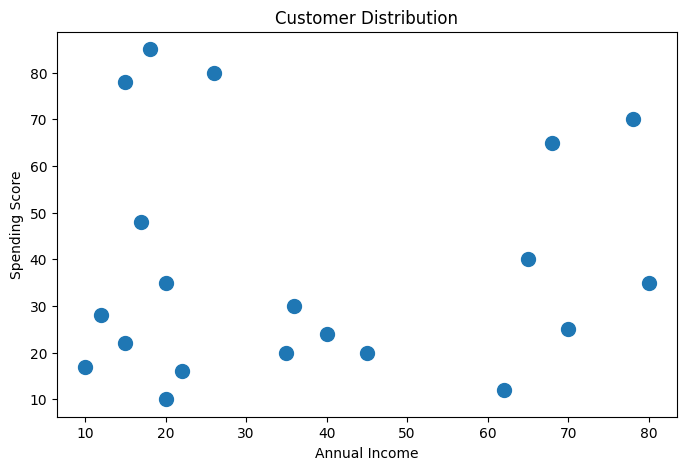

In [5]:
# Visualize the relationship between Annual_Income and Spending_Score
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    s = 100
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")

plt.show()


**Step-6 : Select Features**

In [6]:
#Select three relevent feature for customer segementation.
features = [
    "Age",
    "Annual_Income",
    "Spending_Score"
]

X = df[features]
X.head()

,Age,Annual_Income,Spending_Score
0,19,15,78
1,21,26,80
2,20,18,85
3,31,17,48
4,22,45,20


**Step-7 : Fetures Scaling**

In [7]:
# Use StandarScaler to normalize features with different scales.
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.39083349, -0.96511896,  1.68535004],
       [-1.19285007, -0.49744017,  1.76961754],
       [-1.29184178, -0.8375702 ,  1.9802863 ],
       [-0.202933  , -0.88008645,  0.42133751],
       [-1.09385837,  0.31036865, -0.75840752]])

**Step-8 : Find  the Best K using Eibow Method**

In [8]:
# Calculate WCSS for different values of K.
wcss = []
for k in range(1, 11):
  kmeans = KMeans(
      n_clusters = k,
      random_state = 42,
      n_init = 10
  )

  kmeans.fit(X_scaled)

  wcss.append(kmeans.inertia_)


**Step-9 : Plot Elbow Curve**

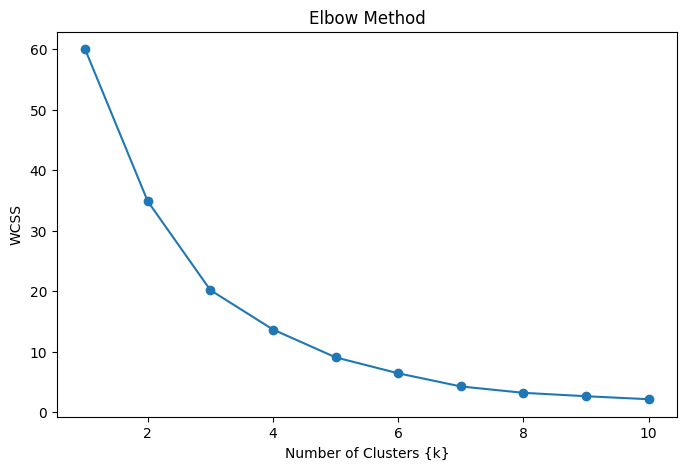

In [9]:
# Plot the relationship between K ans WCSS using the Elbow Method.
plt.figure(figsize = (8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker = "o"
)

plt.xlabel("Number of Clusters {k}")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

**Step-10 :Train the Final K-Means Model**

In [10]:
kmeans = KMeans(
    n_clusters = 7,
    random_state = 42,
    n_init = 10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=7, n_init=10, random_state=42)

**Step-11 : Get Cluster Labels**

In [11]:
labels = kmeans.labels_

labels

array([1, 1, 1, 3, 6, 2, 5, 2, 3, 6, 4, 4, 0, 0, 0, 0, 5, 5, 3, 2],
      dtype=int32)

**Step-12 : Add Cluster to Dataset**

In [12]:
df["Cluster"] = labels

df

,Customer_ID,Age,Annual_Income,Spending_Score,Cluster
0,1,19,15,78,1
1,2,21,26,80,1
2,3,20,18,85,1
3,4,31,17,48,3
4,5,22,45,20,6
5,6,32,70,25,2
6,7,35,36,30,5
7,8,40,80,35,2
8,9,30,20,10,3
9,10,28,62,12,6


**Step-13 : Visualize Customer Segments**

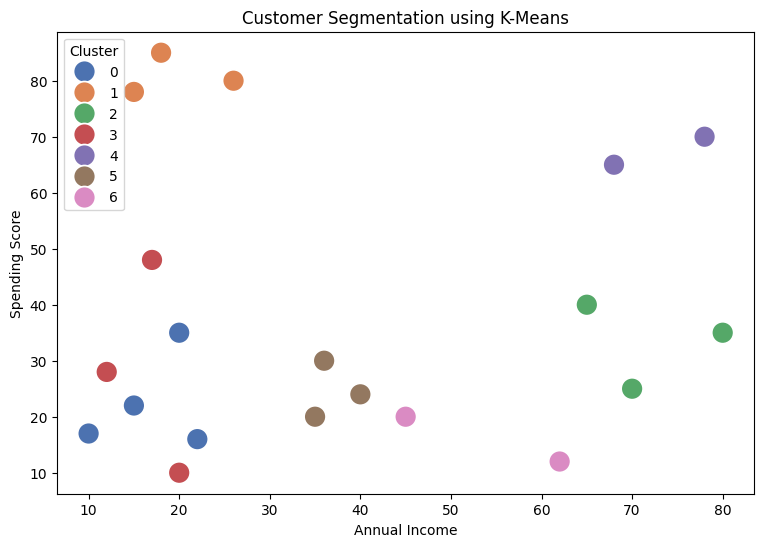

In [13]:
# Visualize the distribution of customers in each cluster.
plt.figure(figsize = (9, 6))

sns.scatterplot(
    data = df,
    x = "Annual_Income",
    y = "Spending_Score",
    hue = "Cluster",
    palette = "deep",
    s = 250
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.show()

**Step-14 : Display Centroids**

In [14]:
centroids_scaled = kmeans.cluster_centers_

centroids = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(
    centroids,
    columns = features
)

centroid_df

,Age,Annual_Income,Spending_Score
0,48.750000,16.750000,22.500000
1,20.000000,19.666667,81.000000
2,35.000000,71.666667,33.333333
3,29.000000,16.333333,28.666667
4,24.500000,73.000000,67.500000
5,38.333333,37.000000,24.666667
6,25.000000,53.500000,16.000000


**Step-15 : Calculate Silhouette Score**

In [15]:
silhouette = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score : ", silhouette)

Silhouette Score :  0.49097879057516103


**Step-16 : Analyze Each Custoemr Segment**

In [16]:
# Calculate the average customer characteristics for each cluster.
cluster_summery = df.groupby("Cluster")[
    ["Age", "Annual_Income", "Spending_Score"]
].mean()

cluster_summery

,Age,Annual_Income,Spending_Score
Cluster,,,
0,48.750000,16.750000,22.500000
1,20.000000,19.666667,81.000000
2,35.000000,71.666667,33.333333
3,29.000000,16.333333,28.666667
4,24.500000,73.000000,67.500000
5,38.333333,37.000000,24.666667
6,25.000000,53.500000,16.000000


Step-17 : Give Business Meaning to Clusters

In [17]:
# Interpret each cluster based on customer Characterstics
cluster_names = {
    0 : "Old, Low Income and Low Spending Customers",
    1 : "Young, Low Income and High Spending Customers",
    2 : "Middle, High Income and Average Spending Customers",
    3 : "Middle, Low Income and Average Spending Customers",
    4 : "Young, High Income and High Spending Customers",
    5 : "Middle, Average Income and Low Spending Customers",
    6 : "Young, High Income and Low Spending Customers"
}

df["Customer_Segments"] = df["Cluster"].map(cluster_names)
df

,Customer_ID,Age,Annual_Income,Spending_Score,Cluster,Customer_Segments
0,1,19,15,78,1,"Young, Low Income and High Spending Customers"
1,2,21,26,80,1,"Young, Low Income and High Spending Customers"
2,3,20,18,85,1,"Young, Low Income and High Spending Customers"
3,4,31,17,48,3,"Middle, Low Income and Average Spending Customers"
4,5,22,45,20,6,"Young, High Income and Low Spending Customers"
5,6,32,70,25,2,"Middle, High Income and Average Spending Custo..."
6,7,35,36,30,5,"Middle, Average Income and Low Spending Customers"
7,8,40,80,35,2,"Middle, High Income and Average Spending Custo..."
8,9,30,20,10,3,"Middle, Low Income and Average Spending Customers"
9,10,28,62,12,6,"Young, High Income and Low Spending Customers"


**Step-18 : Final Customer Segmentation Result**

In [18]:
final_result = df[
    [
        "Customer_ID",
        "Age",
        "Annual_Income",
        "Spending_Score",
        "Customer_Segments"
    ]
]

final_result

,Customer_ID,Age,Annual_Income,Spending_Score,Customer_Segments
0,1,19,15,78,"Young, Low Income and High Spending Customers"
1,2,21,26,80,"Young, Low Income and High Spending Customers"
2,3,20,18,85,"Young, Low Income and High Spending Customers"
3,4,31,17,48,"Middle, Low Income and Average Spending Customers"
4,5,22,45,20,"Young, High Income and Low Spending Customers"
5,6,32,70,25,"Middle, High Income and Average Spending Custo..."
6,7,35,36,30,"Middle, Average Income and Low Spending Customers"
7,8,40,80,35,"Middle, High Income and Average Spending Custo..."
8,9,30,20,10,"Middle, Low Income and Average Spending Customers"
9,10,28,62,12,"Young, High Income and Low Spending Customers"


**Step-19 : Prefict a New Customer**

In [19]:
new_customer = pd.DataFrame({
    "Age" : 25,
    "Annual_Income" : [30],
    "Spending_Score" : [80]
})

new_customer

new_customer_scaled =  scaler.transform(new_customer)

new_cluster = kmeans.predict(new_customer_scaled)

print("New Customer Cluster : ", new_cluster[0])
print("Cluster Segment : ", cluster_names[new_cluster[0]])

New Customer Cluster :  1
Cluster Segment :  Young, Low Income and High Spending Customers


**Step-20 : Add Gradio UI**

In [20]:
# Install Gradio
!pip install gradio -q


In [21]:

# import Gradio
import gradio as gr

#==========================
#Create Prediction Function
#==========================
#Create a DataFrame for the new Customer

def predict_customer(age, income, spending):

  new_customer = pd.DataFrame({
      "Age" : [age],
      "Annual_Income" : [income],
      "Spending_Score" : [spending]
  })

  # Scale the new customer using same fitted scaler
  new_customer_scaled = scaler.transform(new_customer)

  # Predict the cluster for the new customer
  cluster = kmeans.predict(new_customer_scaled)[0]

  # Get the segment name for the cluster number
  segment = cluster_names[cluster]

  # Create a result message
  result = f"""
  Customer Segmentation Result

  Cluster Number : {cluster}

  Customer Segment : {segment}
  """

  return result

#=========================================
# Create Cluster Visualization
#=========================================
def create_plot():

  # Create a figure
  fig, ax = plt.subplots(figsize = (9, 6))

  # Plot customer according to their cluster.
  sns.scatterplot(
      data = df,
      x = "Annual_Income",
      y = "Spending_Score",
      hue = "Cluster",
      palette = "deep",
      s = 120,
      ax = ax
  )

  # Plot the customer centroids
  ax.scatter(
      centroid_df["Annual_Income"],#centroids[:,1],
      centroid_df["Spending_Score"],#centroids[:,2],
      s = 300,
      marker = "X",
      c = "black",
      label = "Centroids"
  )

  # Set the X-axis label
  ax.set_xlabel("Annual Income")

  # Y-axis
  ax.set_ylabel("Spending Score")

  # Chart title
  ax.set_title("Customer Segmentation using K-Means")

  # Display legend
  ax.legend()

  # Return the figure
  return fig



In [22]:
#===============================
#Create Gradio UI with Block
#===============================
with gr.Blocks() as app:
  gr.Markdown("""# 🛍️Customer Segmentation Using K-Means

  Enter Customer Information to predict the customer's segment.
  """)

  gr.Markdown("## Customer Information")

  with gr.Row():
    age_input = gr.Number(label = "Age", value = 25)
    income_input = gr.Number(label = "Annual Income", value = 30)
    spending_input = gr.Number(label = "Spending Score", value = 80)

  button = gr.Button("🔎Predict Customer Segment")

  gr.Markdown("## Prediction Result")

  result_output = gr.Textbox(label = "Customer Segment")

  gr.Markdown("## 📊Customer Segmentation Visualization")

  output_plot = gr.Plot(label = "Customer Cluster")

  button.click(
      fn = predict_customer,
      inputs = [age_input, income_input, spending_input],
      outputs = result_output
  )

  app.load(
      fn = create_plot,
      inputs = None,
      outputs = output_plot
  )


#launch
app.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b2b041be0cbd94c2d5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
